In [ ]:
!cat /proc/cpuinfo
!nvidia-smi

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.152
cache size	: 39424 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch invpcid_single ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmi

In [ ]:
from google.colab import  drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install transformers datasets seqeval torch

In [ ]:
#from transformers import BertTokenizer
import unicodedata
import os
import numpy as np
import json
from sklearn.model_selection import train_test_split

In [ ]:
#dataset_path = '/content/drive/MyDrive/datasets/joint_extraction/dnrti_bert.json'

dataset_path ='/content/drive/MyDrive/datasets/joint_extraction/dnrti_for_je.json'

def write_to_file(dataset, filename):
    with open(filename, 'w') as file:
        json.dump(dataset, file, indent=4)
# Load the dataset
with open(dataset_path, 'r') as f:
    data = json.load(f)

# Split the dataset into train, test, and validation sets
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Training data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")



Training data size: 5263
Validation data size: 658
Test data size: 658


In [ ]:
dataset_path = 'train.json'
write_to_file(train_data, dataset_path)
dataset_path = 'dev.json'
write_to_file(val_data, dataset_path)
dataset_path = 'test.json'
write_to_file(test_data, dataset_path)

In [ ]:
train_data[0]

{'text': 'In this same time frame , APT10 also targeted a U.S. law firm and an international apparel company , likely to gather information for commercial advantage .',
 'entities': [[6, 7, 'APT10', 'HackOrg'],
  [10, 13, 'U.S. law firm', 'Org'],
  [16, 18, 'apparel company', 'Org'],
  [21, 23, 'gather information', 'Purp']],
 'relations': [['targets', 1, 0],
  ['targets', 2, 0],
  ['motivatedBy', 3, 0],
  ['noRelation', 2, 1],
  ['noRelation', 3, 1],
  ['noRelation', 3, 2]],
 'ent_labels': ['O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-HackOrg',
  'O',
  'O',
  'O',
  'B-Org',
  'I-Org',
  'I-Org',
  'O',
  'O',
  'O',
  'B-Org',
  'I-Org',
  'O',
  'O',
  'O',
  'B-Purp',
  'I-Purp',
  'O',
  'O',
  'O',
  'O']}

In [ ]:
train_data[3]

{'text': 'PUTTER PANDA is a determined adversary group , conducting intelligence-gathering operations targeting the Government , Defense , Research , and Technology sectors in the United States , with specific targeting of the US Defense and European satellite and aerospace industries .',
 'entities': [[0, 2, 'PUTTER PANDA', 'HackOrg'],
  [9, 10, 'intelligence-gathering', 'Purp'],
  [13, 14, 'Government', 'Org'],
  [15, 16, 'Defense', 'Org'],
  [17, 18, 'Research', 'Org'],
  [20, 22, 'Technology sectors', 'Org'],
  [24, 26, 'United States', 'Area'],
  [32, 34, 'US Defense', 'Org'],
  [35, 36, 'European', 'Area'],
  [36, 37, 'satellite', 'Org'],
  [38, 40, 'aerospace industries', 'Org']],
 'relations': [['motivatedBy', 1, 0],
  ['targets', 2, 0],
  ['targets', 3, 0],
  ['targets', 4, 0],
  ['targets', 5, 0],
  ['targets', 6, 0],
  ['targets', 7, 0],
  ['targets', 8, 0],
  ['targets', 9, 0],
  ['targets', 10, 0],
  ['noRelation', 2, 1],
  ['noRelation', 3, 1],
  ['noRelation', 4, 1],
  [

In [ ]:
for i in range(5):
  print(train_data[i])

{'text': 'In this same time frame , APT10 also targeted a U.S. law firm and an international apparel company , likely to gather information for commercial advantage .', 'entities': [[6, 7, 'APT10', 'HackOrg'], [10, 13, 'U.S. law firm', 'Org'], [16, 18, 'apparel company', 'Org'], [21, 23, 'gather information', 'Purp']], 'relations': [['targets', 1, 0], ['targets', 2, 0], ['motivatedBy', 3, 0], ['noRelation', 2, 1], ['noRelation', 3, 1], ['noRelation', 3, 2]], 'ent_labels': ['O', 'O', 'O', 'O', 'O', 'O', 'B-HackOrg', 'O', 'O', 'O', 'B-Org', 'I-Org', 'I-Org', 'O', 'O', 'O', 'B-Org', 'I-Org', 'O', 'O', 'O', 'B-Purp', 'I-Purp', 'O', 'O', 'O', 'O']}
{'text': 'Since August 2018 , the Machete components have been delivered with an extra layer of obfuscation .', 'entities': [[1, 3, 'August 2018', 'Time'], [5, 6, 'Machete', 'HackOrg']], 'relations': [['hasAttackTime', 1, 0]], 'ent_labels': ['O', 'B-Time', 'I-Time', 'O', 'O', 'B-HackOrg', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}
{'

In [ ]:
for i in range(5):
  print(test_data[i])

{'text': 'Once downloaded and executed , it drops an intermediate payload that further downloads a Pony DLL and Vawtrak executable , which perform data theft and connect to a command and control (C2) server .', 'entities': [[14, 16, 'Pony DLL', 'SamFile'], [17, 18, 'Vawtrak', 'SamFile'], [22, 24, 'data theft', 'Features'], [25, 26, 'connect', 'Features'], [28, 29, 'command', 'Purp'], [30, 33, 'control (C2) server', 'Purp']], 'relations': [['noRelation', 1, 0], ['hasCharacteristics', 2, 0], ['hasCharacteristics', 3, 0], ['motivatedBy', 4, 0], ['motivatedBy', 5, 0], ['hasCharacteristics', 2, 1], ['hasCharacteristics', 3, 1], ['motivatedBy', 4, 1], ['motivatedBy', 5, 1], ['noRelation', 3, 2], ['noRelation', 4, 2], ['noRelation', 5, 2], ['noRelation', 4, 3], ['noRelation', 5, 3], ['noRelation', 5, 4]], 'ent_labels': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-SamFile', 'I-SamFile', 'O', 'B-SamFile', 'O', 'O', 'O', 'O', 'B-Features', 'I-Features', 'O', 'B-Featu

In [ ]:
# model_name = "ehsanaghaei/SecureBERT"
#model_name = "ehsanaghaei/SecureBERT_Plus"
model_name = "roberta-base"

In [ ]:
from transformers import RobertaTokenizerFast, RobertaModel
import unicodedata

class RoBERTTextEncoder(object):
    def __init__(self, model_name, do_lower_case: bool = True) -> None:
        # Load AutoTokenizer for the pre-trained model
        #self.tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=do_lower_case)

        self.tokenizer = RobertaTokenizerFast.from_pretrained(model_name, add_prefix_space=True)

    def tokenize(self, text):
        """Tokenize input text using AutoTokenizer and return token data."""
        # Tokenize using AutoTokenizer with word-level and subword information
        encoding = self.tokenizer(text, return_offsets_mapping=True, is_split_into_words=False)

        tokens = encoding.tokens()  # Actual tokens
        token_ids = encoding['input_ids']  # Token IDs
        offset_mapping = encoding['offset_mapping']  # Character-level offsets for each token
        word_ids = encoding.word_ids()  # Word-level mapping is extracted here

        return tokens, token_ids, offset_mapping, word_ids

    def convert_tokens_to_ids(self, tokens):
        return self.tokenizer.convert_tokens_to_ids(tokens)

    def convert_ids_to_tokens(self, token_ids):
        """Converts token IDs back to tokens."""
        return self.tokenizer.convert_ids_to_tokens(token_ids)


In [ ]:
import os

roberta_encoder = RoBERTTextEncoder(model_name)

projectName = 'relation_extraction_bert_attention_model_joint_NER_RC_task'


neid2type = {
    0: 'null',      # null class
    1: 'O',
    2: 'B-Area',
    3: 'I-Area',
    4: 'B-Exp',
    5: 'I-Exp',
    6: 'B-Features',
    7: 'I-Features',
    8: 'B-HackOrg',
    9: 'I-HackOrg',
    10: 'B-OffAct',
    11: 'I-OffAct',
    12: 'B-Org',
    13: 'I-Org',
    14: 'B-Purp',
    15: 'I-Purp',
    16: 'B-SamFile',
    17: 'I-SamFile',
    18: 'B-SecTeam',
    19: 'I-SecTeam',
    20: 'B-Time',
    21: 'I-Time',
    22: 'B-Tool',
    23: 'I-Tool',
    24: 'B-Way',
    25: 'I-Way'
    }

# # RE relation types (provided by you)
# reid2type = {
#     0: 'null',          # null class for no relation
#     1: 'noRelation',
#     2: 'targets',
#     3: 'uses',
#     4: 'locatedAt',
#     5: 'hasAttackTime',
#     6: 'hasCharacteristics',
#     7: 'associatedWith',
#     8: 'discovers',
#     9: 'monitors',
#     10: 'motivates',
#     11: 'analyses'
# }

reid2type = {
    0: 'null',          # null class for no relation
    1: 'noRelation',
    2: 'targets',
    3: 'uses',
    4: 'locatedAt',
    5: 'hasAttackTime',
    6: 'hasCharacteristics',
    7: 'associatedWith',
    8: 'discovers',
    9: 'monitors',
    10: 'motivates',
    11: 'analyses',
    12: 'targetedBy',
    13: 'usedBy',
    14: 'discoveredBy',
    15: 'monitoredBy',
    16: 'motivatedBy'
}

# Create reverse mappings for entity and relation types
netype2id = {v: k for k, v in neid2type.items()}
retype2id = {v: k for k, v in reid2type.items()}

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [ ]:
netype2id, neid2type

({'null': 0,
  'O': 1,
  'B-Area': 2,
  'I-Area': 3,
  'B-Exp': 4,
  'I-Exp': 5,
  'B-Features': 6,
  'I-Features': 7,
  'B-HackOrg': 8,
  'I-HackOrg': 9,
  'B-OffAct': 10,
  'I-OffAct': 11,
  'B-Org': 12,
  'I-Org': 13,
  'B-Purp': 14,
  'I-Purp': 15,
  'B-SamFile': 16,
  'I-SamFile': 17,
  'B-SecTeam': 18,
  'I-SecTeam': 19,
  'B-Time': 20,
  'I-Time': 21,
  'B-Tool': 22,
  'I-Tool': 23,
  'B-Way': 24,
  'I-Way': 25},
 {0: 'null',
  1: 'O',
  2: 'B-Area',
  3: 'I-Area',
  4: 'B-Exp',
  5: 'I-Exp',
  6: 'B-Features',
  7: 'I-Features',
  8: 'B-HackOrg',
  9: 'I-HackOrg',
  10: 'B-OffAct',
  11: 'I-OffAct',
  12: 'B-Org',
  13: 'I-Org',
  14: 'B-Purp',
  15: 'I-Purp',
  16: 'B-SamFile',
  17: 'I-SamFile',
  18: 'B-SecTeam',
  19: 'I-SecTeam',
  20: 'B-Time',
  21: 'I-Time',
  22: 'B-Tool',
  23: 'I-Tool',
  24: 'B-Way',
  25: 'I-Way'})

In [ ]:
# def tokenize_and_align_labels(robert_encoder, text, entity_labels, label2id):
#     # Preprocess text to handle abbreviations like "U.S."
#     preprocessed_text = preprocess_text(text)

#     # Tokenize the preprocessed text using BERTTextEncoder's tokenize function
#     tokens, token_ids, offset_mapping, word_ids = robert_encoder.tokenize(preprocessed_text)

#     aligned_labels = []
#     prev_word_id = None

#     print(f"Tokens: {tokens}")
#     print(f"Word IDs: {word_ids}")
#     print(f"length of tokens: {len(tokens)}")
#     print(f"length of word_ids: {len(word_ids)}")

#     # Align labels to tokens using the word_ids
#     for idx, word_id in enumerate(word_ids):
#         if word_id is None:
#             aligned_labels.append(label2id["O"])  # Use "O" for special tokens like [CLS], [SEP]
#         elif word_id == prev_word_id:
#             aligned_labels.append(aligned_labels[-1])  # If same word split into subwords
#         else:
#             # Get the label corresponding to the original word index
#             label = entity_labels[word_id] if word_id < len(entity_labels) else "O"
#             aligned_labels.append(label2id.get(label, label2id["O"]))
#         prev_word_id = word_id

#     return tokens, aligned_labels, token_ids

def fix_word_ids(word_ids, idx):
  for k in range(idx, len(word_ids)):
    if word_ids[k] is not None:
      word_ids[k] -= 1
  return word_ids

def tokenize_and_align_labels(robert_encoder, text, entity_labels, label2id):
    # Preprocess text to handle abbreviations like "U.S."
    preprocessed_text = preprocess_text(text)

    # Tokenize the preprocessed text using RoBERTTextEncoder's tokenize function
    tokens, token_ids, offset_mapping, word_ids = robert_encoder.tokenize(preprocessed_text)

    aligned_labels = []
    prev_word_id = None
    #print(f"Word IDs before: {word_ids}")

    # Post-process word_ids based on subword indicators
    for idx in range(len(tokens)):
        # If the token does not start with 'Ġ' and is not a special token, inherit the previous word_id
        if idx > 0 and not tokens[idx].startswith('Ġ') and word_ids[idx] is not None and tokens[idx] != '.':
            if word_ids[idx] != word_ids[idx - 1]:
                # print(f"Word ID to fix: {word_ids[idx]}")
                # print(f"idx+1: {idx+1}")
                word_ids[idx] = word_ids[idx - 1]
                word_ids = fix_word_ids(word_ids, idx+1)

    # print(f"Tokens: {tokens}")
    # print(f"Word IDs after: {word_ids}")
    # print(f"length of tokens: {len(tokens)}")
    # print(f"length of word_ids: {len(word_ids)}")

    # Align labels to tokens using the word_ids
    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            aligned_labels.append(label2id["O"])  # Use "O" for special tokens like [CLS], [SEP]
        elif word_id == prev_word_id:
            aligned_labels.append(aligned_labels[-1])  # If same word split into subwords
        else:
            # Get the label corresponding to the original word index
            label = entity_labels[word_id] if word_id < len(entity_labels) else "O"
            aligned_labels.append(label2id.get(label, label2id["O"]))
        prev_word_id = word_id

    return tokens, aligned_labels, token_ids



In [ ]:
def fix_word_ids(word_ids, idx):
  for k in range(idx, len(word_ids)):
    if word_ids[k] is not None:
      word_ids[k] -= 1
  return word_ids

word_ids = [None, 0, 1, 2, 3, 4, 5, 6, 6, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, None]
word_ids = fix_word_ids(word_ids, 6)
print(word_ids)

[None, 0, 1, 2, 3, 4, 4, 5, 5, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, None]


In [ ]:
import re
def preprocess_text(text):
    # Match abbreviations like "U.S.", "A.T.P.", etc., and ensure the final period is optional but removed
    abbreviation_pattern = re.compile(r'\b([A-Z])\.([A-Z])(?:\.([A-Z]))?\b\.')

    # Replace abbreviations by removing the periods
    modified_text = abbreviation_pattern.sub(lambda m: ''.join(m.groups('')), text)

    return modified_text

# Example usage
text = "In this same time frame, APT10 also targeted a U.S. law firm and an international apparel company."
modified_text = preprocess_text(text)
print(modified_text)

In this same time frame, APT10 also targeted a US law firm and an international apparel company.


In [ ]:
text = "In this same time frame , APT10 also targeted a U.S. law firm and an international apparel company , likely to gather information for commercial advantage."
text.split()

['In',
 'this',
 'same',
 'time',
 'frame',
 ',',
 'APT10',
 'also',
 'targeted',
 'a',
 'U.S.',
 'law',
 'firm',
 'and',
 'an',
 'international',
 'apparel',
 'company',
 ',',
 'likely',
 'to',
 'gather',
 'information',
 'for',
 'commercial',
 'advantage.']

In [ ]:
#text = "In this same time frame , APT10 also targeted a U.S. law firm and an international apparel company , likely to gather information for commercial advantage."
text = "Since August 2018 , the Machete components have been delivered with an extra layer of obfuscation "
ent_labels = [
    "O", "O", "O", "O", "O", "O", "B-HackOrg", "O", "O", "O",
    "B-Org", "I-Org", "I-Org", "O", "O", "O", "B-Org", "I-Org",
    "O", "O", "O", "B-Purp", "I-Purp", "O", "O", "O", "O"
]
ent_labels =  ['O', 'B-Time', 'I-Time', 'O', 'O', 'B-HackOrg', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
#netype2id = {'null': 0, 'O': 1, 'B-HackOrg': 8, 'I-HackOrg': 9, 'B-Org': 12, 'I-Org': 13, 'B-Purp': 14, 'I-Purp': 15}
netype2id = {'null': 0,
  'O': 1,
  'B-Area': 2,
  'I-Area': 3,
  'B-Exp': 4,
  'I-Exp': 5,
  'B-Features': 6,
  'I-Features': 7,
  'B-HackOrg': 8,
  'I-HackOrg': 9,
  'B-OffAct': 10,
  'I-OffAct': 11,
  'B-Org': 12,
  'I-Org': 13,
  'B-Purp': 14,
  'I-Purp': 15,
  'B-SamFile': 16,
  'I-SamFile': 17,
  'B-SecTeam': 18,
  'I-SecTeam': 19,
  'B-Time': 20,
  'I-Time': 21,
  'B-Tool': 22,
  'I-Tool': 23,
  'B-Way': 24,
  'I-Way': 25}

# Initialize the BERTTextEncoder
roberta_encoder = RoBERTTextEncoder(model_name)

# Tokenize and align the labels
tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(roberta_encoder, text, ent_labels, netype2id)

print(f"Aligned Labels: {aligned_labels}")
print(f"length of aligned_labels: {len(aligned_labels)}")
print(f"Tokenized Inputs: {tokenized_inputs}")
print(f"Tokens: {tokens}")
tokens2ids = roberta_encoder.convert_tokens_to_ids(tokens)
print(f"Tokens2Ids: {tokens2ids}")
ids2tokens = roberta_encoder.convert_ids_to_tokens(tokens2ids)
print(f"Ids2Tokens: {ids2tokens}")
labels = [neid2type[label] for label in aligned_labels]
# Print the token-label pairs
for token, label in zip(tokens, labels):
    print(f'{token:15} {label}')


Aligned Labels: [1, 1, 20, 21, 1, 1, 8, 8, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
length of aligned_labels: 22
Tokenized Inputs: [0, 1773, 830, 199, 2156, 5, 1775, 700, 859, 6411, 33, 57, 2781, 19, 41, 1823, 10490, 9, 42930, 1258, 1437, 2]
Tokens: ['<s>', 'ĠSince', 'ĠAugust', 'Ġ2018', 'Ġ,', 'Ġthe', 'ĠMac', 'he', 'te', 'Ġcomponents', 'Ġhave', 'Ġbeen', 'Ġdelivered', 'Ġwith', 'Ġan', 'Ġextra', 'Ġlayer', 'Ġof', 'Ġobfusc', 'ation', 'Ġ', '</s>']
Tokens2Ids: [0, 1773, 830, 199, 2156, 5, 1775, 700, 859, 6411, 33, 57, 2781, 19, 41, 1823, 10490, 9, 42930, 1258, 1437, 2]
Ids2Tokens: ['<s>', 'ĠSince', 'ĠAugust', 'Ġ2018', 'Ġ,', 'Ġthe', 'ĠMac', 'he', 'te', 'Ġcomponents', 'Ġhave', 'Ġbeen', 'Ġdelivered', 'Ġwith', 'Ġan', 'Ġextra', 'Ġlayer', 'Ġof', 'Ġobfusc', 'ation', 'Ġ', '</s>']
<s>             O
ĠSince          O
ĠAugust         B-Time
Ġ2018           I-Time
Ġ,              O
Ġthe            O
ĠMac            B-HackOrg
he              B-HackOrg
te              B-HackOrg
Ġcomponents     O
Ġhave     

In [ ]:
def generate_mapped_entities(tokens, labels):
    maped_entities = []
    token_label_pairs = list(zip(tokens, labels))
    idx = 0

    while idx < len(token_label_pairs):
        token, label = token_label_pairs[idx]

        if label.startswith('B-'):  # Beginning of an entity
            start_idx = idx
            entity_type = label[2:]  # Get the entity type (e.g., 'HackOrg')

            # Move to the next token and continue until we no longer find subwords or I-* labels
            while (idx + 1 < len(token_label_pairs) and
                   (token_label_pairs[idx + 1][1].startswith('I-') or (not token_label_pairs[idx + 1][0].startswith('Ġ')) and token_label_pairs[idx + 1][0] != '.')):
                idx += 1

            # End of the entity (the current idx is the last token of the entity)
            end_idx = idx + 1
            maped_entities.append((start_idx, end_idx, entity_type))

        idx += 1

    return maped_entities


tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(roberta_encoder, text, ent_labels, netype2id)

labels = [neid2type[label] for label in aligned_labels]
maped_entities = generate_mapped_entities(tokens, labels)

# Print the mapped entities with start and end indexes
for entity in maped_entities:
    print(f"Entity: {entity[2]}, Start: {entity[0]}, End: {entity[1]}")

Entity: Time, Start: 2, End: 4
Entity: HackOrg, Start: 6, End: 9


In [ ]:
def generate_pos_ids(batch_size: int, max_len: int) -> np.array:
    return np.repeat(np.arange(max_len, dtype=np.int32).reshape(1, -1), batch_size, 0)

In [ ]:
data_path = '/content/'
max_len = 150

In [ ]:
import numpy as np
from tqdm import tqdm
from tensorflow.keras.utils import to_categorical

def re_data_to_input_output(model_data, bert_encoder, max_len):
    input_ids, input_masks, input_entity_masks = [], [], []
    output_re_ids, output_ne_ids = [], []
    entity_type_ids = []  # New list to hold entity type IDs

    for item in tqdm(model_data):
        # Extract the full sentence from the 'text' key
        text = item['text']
        entities = item['entities']
        relations = item['relations']
        ent_labels = item['ent_labels']

        # print(f"\nProcessing text: {text}")
        # print(f"Entities: {entities}")
        # print(f"Relations: {relations}")
        # print(f"Entity Labels (BIO): {ent_labels}")

        # Tokenize and align labels
        tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(roberta_encoder, text, ent_labels, netype2id)

        # print(f"Tokenized sentence: {tokens}")
        # print(f"Aligned labels: {aligned_labels}")

        # Convert aligned labels to their corresponding indices
        labels = [neid2type[label] for label in aligned_labels]
       # print(f"NER Labels for each token: {labels}")

        mapped_entities = generate_mapped_entities(tokens, labels)
        #print(f"Mapped Entities: {mapped_entities}")

        # Create the relation mapping
        #relation_map = {(start_entity_idx, end_entity_idx): relation_type for relation_type, start_entity_idx, end_entity_idx in relations}
        relation_map = {(start_entity_idx, end_entity_idx): relation_type for relation_type, end_entity_idx, start_entity_idx in relations}
        #print(f"Relation Map: {relation_map}")

        # Initialize BIO tags for each token
        netype_list = ['O'] * len(tokens)
        input_id = tokenized_inputs

        # Assign BIO tags based on the mapped entities
        for start_pos, end_pos, entity_type in mapped_entities:
            if end_pos - start_pos == 1:
                netype_list[start_pos] = "B-" + entity_type  # Single-token entities
            else:
                netype_list[start_pos] = "B-" + entity_type
                for tmp_pos in range(start_pos + 1, end_pos - 1):
                    netype_list[tmp_pos] = "I-" + entity_type
                netype_list[end_pos - 1] = "I-" + entity_type  # Mark the end of the entity with 'I'

        #print(f"BIO Tags for tokens: {netype_list}")

        # Prepare relation extraction inputs
        relation_entity_type_ids = []
        for start_entity_idx in range(len(entities)):
            for end_entity_idx in range(start_entity_idx + 1, len(entities)):
                remask = [0] * len(tokens)  # Reset remask for each entity pair

                # Map the entities to their token positions
                if start_entity_idx < len(mapped_entities) and mapped_entities[start_entity_idx]:
                    for tmp_pos in range(mapped_entities[start_entity_idx][0], mapped_entities[start_entity_idx][1]):
                        remask[tmp_pos] = 1

                if end_entity_idx < len(mapped_entities) and mapped_entities[end_entity_idx]:
                    for tmp_pos in range(mapped_entities[end_entity_idx][0], mapped_entities[end_entity_idx][1]):
                        remask[tmp_pos] = 1

                # Get relation type, default to 'noRelation'
                retype = relation_map.get((start_entity_idx, end_entity_idx), 'noRelation')
                input_tokens = tokens
                start_entity_type = entities[start_entity_idx][3]
                end_entity_type = entities[end_entity_idx][3]

                start_entity_type ='B-'+ start_entity_type
                end_entity_type ='B-'+ end_entity_type
                print(f"Start Entity Type: {start_entity_type}, End Entity Type: {end_entity_type}")
                start_entity_type_id = netype2id[start_entity_type]
                end_entity_type_id = netype2id[end_entity_type]

                #print(f"Start Entity Type: {start_entity_type}, End Entity Type: {end_entity_type}")

                # Convert tokens to IDs and create masks
                #input_id = bert_encoder.standardize_ids(bert_encoder.convert_tokens_to_ids(input_tokens))
                input_mask = [1] * len(input_tokens)
                input_entity_mask = [0] + remask + [0]

                # Convert relation type to ID
                output_re_id = retype2id[retype]

                # Prepare output for NER and RE (Note: We no longer one-hot encode NER labels)
                output_netype_list = ['null'] + netype_list + ['null']
                output_ne_id = [netype2id[item] for item in output_netype_list]  # These remain class indices

                # Padding for input and output sequences
                input_id += [0] * (max_len - len(input_id))
                input_mask += [0] * (max_len - len(input_mask))
                input_entity_mask += [0] * (max_len - len(input_entity_mask))
                output_ne_id += [0] * (max_len - len(output_ne_id))

                input_ids.append(input_id)
                input_masks.append(input_mask)
                input_entity_masks.append(input_entity_mask)
                output_re_ids.append(output_re_id)
                output_ne_ids.append(output_ne_id)  # No one-hot encoding here
                relation_entity_type_ids.append([start_entity_type_id, end_entity_type_id])
        entity_type_ids.extend(relation_entity_type_ids)

    input_ids = np.array(input_ids, dtype=np.int32)
    input_masks = np.array(input_masks, dtype=np.int32)
    input_entity_masks = np.array(input_entity_masks, dtype=np.int32)
    entity_type_ids = np.array(entity_type_ids, dtype=np.int32)
    output_re_ids = np.array(output_re_ids, dtype=np.int32)
    output_ne_ids = np.array(output_ne_ids, dtype=np.int32)  # Should remain as class indices

    # Generate positional IDs and type IDs
    pos = generate_pos_ids(len(input_ids), max_len)
    input_type_ids = np.zeros((len(input_ids), max_len), dtype=np.int32)

    # Prepare y_train outputs
    y_train = [
        output_ne_ids,
       output_re_ids
    ]


    return [input_ids, input_masks, input_entity_masks, entity_type_ids], y_train

In [ ]:
# Load data
train_data = json.load(open(data_path + "train.json"))
dev_data = json.load(open(data_path + "dev.json"))
test_data = json.load(open(data_path + "test.json"))

print(f"Train Data: {len(train_data)}, Dev Data: {len(dev_data)}, Test Data: {len(test_data)}")

# train_data_subset = train_data[:100]
# test_data_subset = test_data[:100]
# dev_data_subset = dev_data[:100]

# Execute the data preparation function
x_train, y_train = re_data_to_input_output(train_data, roberta_encoder, max_len)

Train Data: 5263, Dev Data: 658, Test Data: 658


  3%|▎         | 158/5263 [00:00<00:03, 1575.97it/s]

Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Purp
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Purp
Start Entity Type: B-Org, End Entity Type: B-Purp
Start Entity Type: B-Time, End Entity Type: B-HackOrg
Start Entity Type: B-OffAct, End Entity Type: B-Way
Start Entity Type: B-HackOrg, End Entity Type: B-Purp
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Area
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Area
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-Purp, End Entity Type: B-Org
St

  8%|▊         | 443/5263 [00:00<00:04, 1151.11it/s]

Start Entity Type: B-OffAct, End Entity Type: B-Time
Start Entity Type: B-HackOrg, End Entity Type: B-Purp
Start Entity Type: B-SecTeam, End Entity Type: B-OffAct
Start Entity Type: B-SecTeam, End Entity Type: B-Tool
Start Entity Type: B-SecTeam, End Entity Type: B-Time
Start Entity Type: B-OffAct, End Entity Type: B-Tool
Start Entity Type: B-OffAct, End Entity Type: B-Time
Start Entity Type: B-Tool, End Entity Type: B-Time
Start Entity Type: B-SamFile, End Entity Type: B-Way
Start Entity Type: B-SamFile, End Entity Type: B-Way
Start Entity Type: B-SamFile, End Entity Type: B-Exp
Start Entity Type: B-SamFile, End Entity Type: B-Tool
Start Entity Type: B-SamFile, End Entity Type: B-HackOrg
Start Entity Type: B-SamFile, End Entity Type: B-Time
Start Entity Type: B-Way, End Entity Type: B-Way
Start Entity Type: B-Way, End Entity Type: B-Exp
Start Entity Type: B-Way, End Entity Type: B-Tool
Start Entity Type: B-Way, End Entity Type: B-HackOrg
Start Entity Type: B-Way, End Entity Type: B-Ti

...

Start Entity Type: B-Tool, End Entity Type: B-Area
Start Entity Type: B-Tool, End Entity Type: B-Exp
Start Entity Type: B-Area, End Entity Type: B-Exp
Start Entity Type: B-SecTeam, End Entity Type: B-HackOrg
Start Entity Type: B-HackOrg, End Entity Type: B-Tool
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-HackOrg
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-HackOrg
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Tool
Start Entity Type: B-HackOrg, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Purp
Start Entity Type: B-S

 98%|█████████▊| 5161/5263 [00:05<00:00, 1286.30it/s]

Start Entity Type: B-HackOrg, End Entity Type: B-Exp
Start Entity Type: B-HackOrg, End Entity Type: B-OffAct
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Area
Start Entity Type: B-Exp, End Entity Type: B-OffAct
Start Entity Type: B-Exp, End Entity Type: B-Org
Start Entity Type: B-Exp, End Entity Type: B-Area
Start Entity Type: B-OffAct, End Entity Type: B-Org
Start Entity Type: B-OffAct, End Entity Type: B-Area
Start Entity Type: B-Org, End Entity Type: B-Area
Start Entity Type: B-SamFile, End Entity Type: B-SamFile
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-Tool, End Entity Type: B-OffAct
Start Entity Type: B-Tool, End Entity Type: B-Org
Start Entity Type: B-Tool, End Entity Type: B-Org
Start Entity Type: B-Tool, End Entity Type: B-HackOrg
Start Entity Type: B-Tool, End Entity Type: B-Exp
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Time
Start Ent

100%|██████████| 5263/5263 [00:05<00:00, 976.50it/s] 


Start Entity Type: B-Tool, End Entity Type: B-OffAct
Start Entity Type: B-Tool, End Entity Type: B-Time
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-OffAct, End Entity Type: B-Time
Start Entity Type: B-OffAct, End Entity Type: B-Tool
Start Entity Type: B-Time, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-HackOrg
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-HackOrg
Start Entity Type: B-Tool, End Entity Type: B-OffAct
Start Entity Type: B-HackOrg, End Entity Type: B-Tool
Start Entity Type: B-HackOrg, End Entity Type: B-HackOrg
Start Entity Type: B-HackOrg, End Entity Type: B-OffAct
Start Entity Type: B-Tool, End Entity Type: B-HackOrg
Start Entity Type: B-Tool, End Entity Type: B-OffAct
Start Entity Type: B-HackOrg, End Entity Type: B-OffAct
Start Entity Type: B-SamFile, End Entity Type: B-Features
Start Entity Type: B-SamFile, End Entity Type: B-Tool
Start Entity Type: B-SamFile, End 

In [ ]:
x_dev, y_dev = re_data_to_input_output(dev_data, roberta_encoder, max_len)
x_test, y_test = re_data_to_input_output(test_data, roberta_encoder, max_len)

 25%|██▍       | 162/658 [00:00<00:00, 1598.21it/s]

Start Entity Type: B-Features, End Entity Type: B-Tool
Start Entity Type: B-SamFile, End Entity Type: B-Features
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Features
Start Entity Type: B-Org, End Entity Type: B-Features
Start Entity Type: B-Features, End Entity Type: B-Features
Start Entity Type: B-SecTeam, End Entity Type: B-HackOrg
Start Entity Type: B-SecTeam, End Entity Type: B-Time
Start Entity Type: B-HackOrg, End Entity Type: B-Time
Start Entity Type: B-HackOrg, End Entity Type: B-Time
Start Entity Type: B-HackOrg, End Entity Type: B-OffAct
Start Entity Type: B-HackOrg, End Entity Type: B-Area
Start Entity Type: B-HackOrg, End Entity Type: B-Org
Start Entity Type: B-HackOrg, En

 49%|████▉     | 322/658 [00:00<00:00, 1214.65it/s]

Start Entity Type: B-SamFile, End Entity Type: B-Exp
Start Entity Type: B-Purp, End Entity Type: B-Purp
Start Entity Type: B-Purp, End Entity Type: B-Purp
Start Entity Type: B-Purp, End Entity Type: B-Purp
Start Entity Type: B-HackOrg, End Entity Type: B-Area
Start Entity Type: B-SamFile, End Entity Type: B-Exp
Start Entity Type: B-SamFile, End Entity Type: B-Exp
Start Entity Type: B-SamFile, End Entity Type: B-Exp
Start Entity Type: B-Exp, End Entity Type: B-Exp
Start Entity Type: B-Exp, End Entity Type: B-Exp
Start Entity Type: B-Exp, End Entity Type: B-Exp
Start Entity Type: B-Time, End Entity Type: B-HackOrg
Start Entity Type: B-Time, End Entity Type: B-OffAct
Start Entity Type: B-HackOrg, End Entity Type: B-OffAct
Start Entity Type: B-HackOrg, End Entity Type: B-SamFile
Start Entity Type: B-HackOrg, End Entity Type: B-Exp
Start Entity Type: B-SamFile, End Entity Type: B-Exp
Start Entity Type: B-OffAct, End Entity Type: B-Way
Start Entity Type: B-OffAct, End Entity Type: B-SamFile


 84%|████████▍ | 554/658 [00:00<00:00, 918.49it/s]

...

 66%|██████▋   | 437/658 [00:00<00:00, 694.99it/s]

Start Entity Type: B-SecTeam, End Entity Type: B-HackOrg
Start Entity Type: B-Purp, End Entity Type: B-HackOrg
Start Entity Type: B-Purp, End Entity Type: B-Area
Start Entity Type: B-HackOrg, End Entity Type: B-Area
Start Entity Type: B-OffAct, End Entity Type: B-HackOrg
Start Entity Type: B-OffAct, End Entity Type: B-Exp
Start Entity Type: B-OffAct, End Entity Type: B-Tool
Start Entity Type: B-OffAct, End Entity Type: B-Tool
Start Entity Type: B-HackOrg, End Entity Type: B-Exp
Start Entity Type: B-HackOrg, End Entity Type: B-Tool
Start Entity Type: B-HackOrg, End Entity Type: B-Tool
Start Entity Type: B-Exp, End Entity Type: B-Tool
Start Entity Type: B-Exp, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Area, End Entity Type: B-Area
Start Entity Type: B-Area, End Entity Type: B-Area
Start Entity Type: B-Area, End Entity Type: B-Org
Start Entity Type: B-Area, End Entity Type: B-Org
Start Entity Type: B-Area, End Entity Type: B-Area
Start

 89%|████████▉ | 586/658 [00:00<00:00, 927.51it/s]

Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Tool, End Entity Type: B-Tool
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Area
Start Entity Type: B-Org, End Entity Type: B-Area
Start Entity Type: B-Org, End Entity Type: B-HackOrg
Start Entity Type: B-Org, End Entity Type: B-Purp
Start Entity Type: B-Org, End Entity Type: B-Org
Start Entity Type: B-Org, End Entity Type: B-Area
Start Entity Type: B-Org, End Entity Type: B-Area
Start Entity Type: B-Org, End Entity Type: B-HackOrg
Start Entity Type: B-Org, End Entity

100%|██████████| 658/658 [00:00<00:00, 806.23it/s]


In [ ]:
y_train

[array([[0, 1, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        ...,
        [0, 1, 8, ..., 0, 0, 0],
        [0, 1, 8, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0]], dtype=int32),
 array([ 2,  2, 16, ...,  3,  3, 12], dtype=int32)]

Relation label distribution: {np.int32(1): np.int64(14261), np.int32(2): np.int64(4993), np.int32(3): np.int64(4114), np.int32(4): np.int64(1257), np.int32(5): np.int64(1020), np.int32(6): np.int64(987), np.int32(7): np.int64(603), np.int32(8): np.int64(546), np.int32(9): np.int64(1012), np.int32(10): np.int64(153), np.int32(11): np.int64(139), np.int32(12): np.int64(1018), np.int32(13): np.int64(2146), np.int32(14): np.int64(138), np.int32(15): np.int64(79), np.int32(16): np.int64(934)}


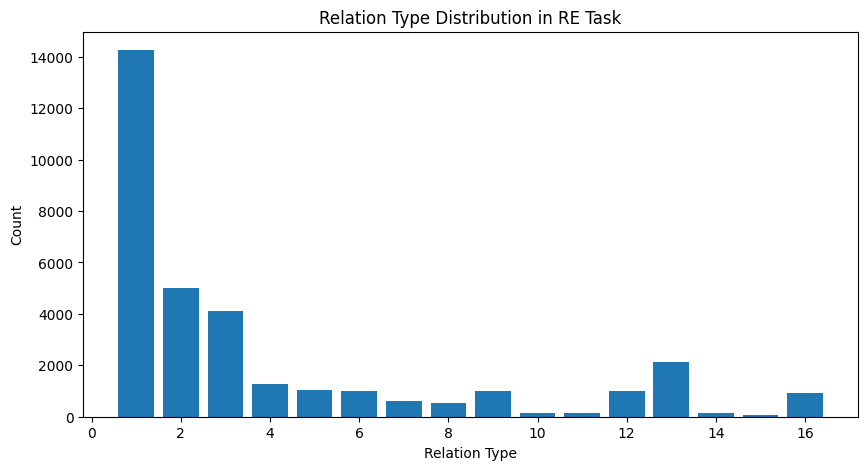

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get RE labels from y_train
re_labels = y_train[1]

# Count the occurrences of each relation type
unique, counts = np.unique(re_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))

# Display the distribution of relation types
print("Relation label distribution:", label_distribution)

# Plot the distribution of relation types
plt.figure(figsize=(10, 5))
plt.bar(label_distribution.keys(), label_distribution.values())
plt.xlabel('Relation Type')
plt.ylabel('Count')
plt.title('Relation Type Distribution in RE Task')
plt.show()


# Oversampling

In [ ]:
from collections import Counter
import numpy as np

# Define the target oversampling counts
#target_oversample = {2: 2000, 5: 2000, 3: 2000, 4: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000, 10: 2500, 11: 2500}
#target_oversample = {1: 18576, 2: 4993, 3: 4114, 4: 2257, 5: 2110, 6: 2087, 7: 2057, 8: 2050, 9: 2212, 10: 2020, 11: 2000}
target_oversample = {1: 18576, 2: 4993, 3: 4114, 4: 2257, 5: 2110, 6: 2087, 7: 2057, 8: 2050, 9: 2212, 10: 2020, 11: 2023, 12: 2018, 13: 3000, 14: 2005, 15: 2000, 16: 2050}

def oversample_classes(x_train, y_train, target_oversample):
    input_ids, attention_mask, entity_mask, entity_type_ids = x_train
    ner_labels, re_labels = y_train

    # Convert everything to lists for easier manipulation
    input_ids = input_ids.tolist()
    attention_mask = attention_mask.tolist()
    entity_mask = entity_mask.tolist()
    entity_type_ids = entity_type_ids.tolist()  # New addition
    ner_labels = ner_labels.tolist()
    re_labels = re_labels.tolist()

    # Create containers for the resampled data
    resampled_input_ids, resampled_attention_mask = input_ids[:], attention_mask[:]
    resampled_entity_mask, resampled_entity_type_ids = entity_mask[:], entity_type_ids[:]
    resampled_ner_labels, resampled_re_labels = ner_labels[:], re_labels[:]

    # Count original class distribution
    class_counter = Counter(re_labels)

    # Oversample based on the defined target counts, but only for classes below the target
    for class_label, target_count in target_oversample.items():
        current_count = class_counter[class_label]

        if current_count < target_count:
            # Get the indices of samples with this class label
            indices = [i for i, label in enumerate(re_labels) if label == class_label]
            additional_samples_needed = target_count - current_count

            # Select samples to oversample, ensuring the required amount is added
            additional_samples = np.random.choice(indices, size=additional_samples_needed, replace=True)

            # Append oversampled data
            resampled_input_ids.extend([input_ids[i] for i in additional_samples])
            resampled_attention_mask.extend([attention_mask[i] for i in additional_samples])
            resampled_entity_mask.extend([entity_mask[i] for i in additional_samples])
            resampled_entity_type_ids.extend([entity_type_ids[i] for i in additional_samples])  # Add entity type IDs
            resampled_ner_labels.extend([ner_labels[i] for i in additional_samples])
            resampled_re_labels.extend([re_labels[i] for i in additional_samples])

    # Convert back to NumPy arrays
    x_train_resampled = [
        np.array(resampled_input_ids, dtype=np.int32),
        np.array(resampled_attention_mask, dtype=np.int32),
        np.array(resampled_entity_mask, dtype=np.int32),
        np.array(resampled_entity_type_ids, dtype=np.int32)  # Include the entity type IDs
    ]
    y_train_resampled = [
        np.array(resampled_ner_labels, dtype=np.int32),
        np.array(resampled_re_labels, dtype=np.int32)
    ]

    return x_train_resampled, y_train_resampled

# Apply the corrected oversampling
x_train_resampled, y_train_resampled = oversample_classes(x_train, y_train, target_oversample)

# New distribution
new_class_distribution = Counter(y_train_resampled[1])
print("Resampled class distribution:", new_class_distribution)



Resampled class distribution: Counter({np.int32(1): 18576, np.int32(2): 4993, np.int32(3): 4114, np.int32(13): 3000, np.int32(4): 2257, np.int32(9): 2212, np.int32(5): 2110, np.int32(6): 2087, np.int32(7): 2057, np.int32(16): 2050, np.int32(8): 2050, np.int32(11): 2023, np.int32(10): 2020, np.int32(12): 2018, np.int32(14): 2005, np.int32(15): 2000})


# Undersampling

In [ ]:
import numpy as np
from collections import Counter

# y_train_resampled[1] should be the RE labels part of y_train
re_labels_resampled = np.array(y_train_resampled[1])

# Set the target count for undersampling "noRelation" (Class 1)
no_relation_target_count = 8000  # You can change this to 7000 or another value as needed

# Get the indices for 'noRelation' class (class 1)
no_relation_indices = np.where(re_labels_resampled == 1)[0]

# Randomly sample the required number of "noRelation" samples
undersample_indices = np.random.choice(no_relation_indices, no_relation_target_count, replace=False)

# Get the indices for the rest of the classes (non-"noRelation")
non_no_relation_indices = np.where(re_labels_resampled != 1)[0]

# Combine the undersampled "noRelation" indices with the non-"noRelation" indices
final_indices = np.concatenate([undersample_indices, non_no_relation_indices])

# Use these indices to filter x_train_resampled and y_train_resampled
x_train_final = [x[final_indices] for x in x_train_resampled]  # Filter each element in x_train_resampled
y_train_final = [
    y_train_resampled[0][final_indices],  # Filter NER labels (part of y_train_resampled)
    re_labels_resampled[final_indices]    # Filter RE labels
]

# Verify the new distribution after undersampling
new_class_distribution = Counter(y_train_final[1])  # Check RE label distribution
print(f"New class distribution after undersampling: {new_class_distribution}")


New class distribution after undersampling: Counter({np.int32(1): 8000, np.int32(2): 4993, np.int32(3): 4114, np.int32(13): 3000, np.int32(4): 2257, np.int32(9): 2212, np.int32(5): 2110, np.int32(6): 2087, np.int32(7): 2057, np.int32(16): 2050, np.int32(8): 2050, np.int32(11): 2023, np.int32(10): 2020, np.int32(12): 2018, np.int32(14): 2005, np.int32(15): 2000})


In [ ]:
x_train_final

[array([[    0,    96,   336, ...,     0,     0,     0],
        [    0,    96,   502, ...,     0,     0,     0],
        [    0, 39509,  9482, ...,     0,     0,     0],
        ...,
        [    0,    20, 36335, ...,     0,     0,     0],
        [    0,   374,   294, ...,     0,     0,     0],
        [    0,  8506,   154, ...,     0,     0,     0]], dtype=int32),
 array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], dtype=int32),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32),
 array([[12, 12],
        [20,  2],
        [12, 12],
        ...,
        [22, 14],
        [22, 14],
        [ 8, 14]], dtype=int32)]

Relation label distribution: {np.int32(1): np.int64(8000), np.int32(2): np.int64(4993), np.int32(3): np.int64(4114), np.int32(4): np.int64(2257), np.int32(5): np.int64(2110), np.int32(6): np.int64(2087), np.int32(7): np.int64(2057), np.int32(8): np.int64(2050), np.int32(9): np.int64(2212), np.int32(10): np.int64(2020), np.int32(11): np.int64(2023), np.int32(12): np.int64(2018), np.int32(13): np.int64(3000), np.int32(14): np.int64(2005), np.int32(15): np.int64(2000), np.int32(16): np.int64(2050)}


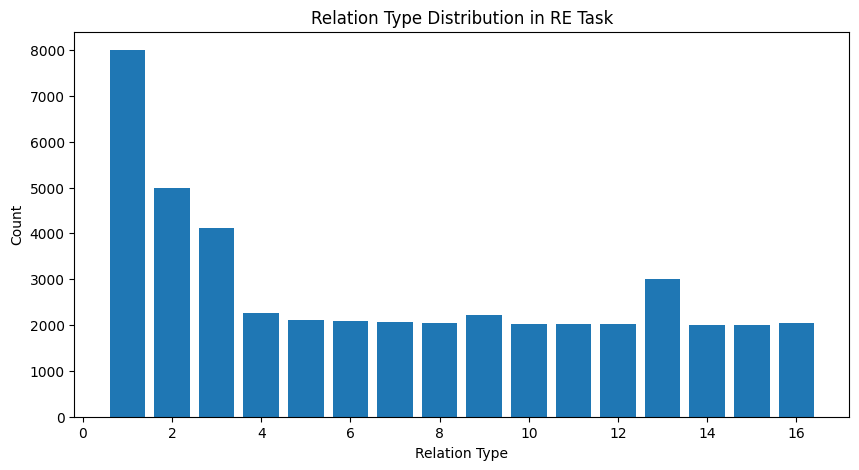

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get RE labels from y_train
re_labels = y_train_final[1]

# Count the occurrences of each relation type
unique, counts = np.unique(re_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))

# Display the distribution of relation types
print("Relation label distribution:", label_distribution)

# Plot the distribution of relation types
plt.figure(figsize=(10, 5))
plt.bar(label_distribution.keys(), label_distribution.values())
plt.xlabel('Relation Type')
plt.ylabel('Count')
plt.title('Relation Type Distribution in RE Task')
plt.show()


In [ ]:

# Verify the shapes of x_train
print(f"x_train shapes: {[x.shape for x in x_train]}")  # Should show shapes of each input array

# Verify the shapes of y_train
print(f"y_train shapes: {[y.shape for y in y_train]}")  # Should show shapes of NER and RE outputs

# Ensure the first element in y_train has the correct shape
print(f"First element of y_train (NER): {y_train[0].shape}")  # Should be (87, 100, num_classes)
print(f"Second element of y_train (RE): {y_train[1].shape}")  # Should be (87,)

x_train shapes: [(33400, 150), (33400, 150), (33400, 150), (33400, 2)]
y_train shapes: [(33400, 150), (33400,)]
First element of y_train (NER): (33400, 150)
Second element of y_train (RE): (33400,)


In [ ]:
# Verify the shapes of x_train
print(f"x_train shapes: {[x.shape for x in x_train_final]}")  # Should show shapes of each input array

# Verify the shapes of y_train
print(f"y_train shapes: {[y.shape for y in y_train_final]}")  # Should show shapes of NER and RE outputs

# Ensure the first element in y_train has the correct shape
print(f"First element of y_train (NER): {y_train_final[0].shape}")  # Should be (87, 100, num_classes)
print(f"Second element of y_train (RE): {y_train_final[1].shape}")  # Should be (87,)

x_train shapes: [(44996, 150), (44996, 150), (44996, 150), (44996, 2)]
y_train shapes: [(44996, 150), (44996,)]
First element of y_train (NER): (44996, 150)
Second element of y_train (RE): (44996,)


In [ ]:
x_train[0][1]

array([    0,    96,    42,   276,    86,  5120,  2156,  1480,   565,
         698,    67,  3656,    10,   382,   488,   933,     8,    41,
         758, 14710,   138,  2156,   533,     7,  7365,   335,    13,
        1861,  2093,   479,     2,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

In [ ]:
x_train[3][1]

array([ 8, 12], dtype=int32)

In [ ]:
# Select a sample to display (for example, the first sample)
sample_idx = 1

# Display tokenized input IDs and masks
print(f"Input tokens (input_ids) for sample {sample_idx}:")
print(x_train[0][sample_idx])  # Token IDs
print("\nInput attention mask (input_masks) for sample:")
print(x_train[1][sample_idx])  # Attention Mask
print("\nEntity mask (input_entity_masks) for sample:")
print(x_train[2][sample_idx])  # Entity Mask
print("\nEntity type IDs (entity_type_ids) for sample:")
print(x_train[3][sample_idx])  # Entity type IDs

# Display NER labels
print("\nNER labels (output_ne_ids) for sample:")
print(y_train[0][sample_idx])  # NER labels

# Display RE labels (output_re_ids)
print("\nRE labels (output_re_ids) for sample:")
print(y_train[1][sample_idx])  # RE labels

# You can also display the tokenized input as words by converting the token IDs back to tokens using the tokenizer:
print("\nTokenized sentence:")
tokens = roberta_encoder.convert_ids_to_tokens(x_train[0][sample_idx])
print(tokens)

Input tokens (input_ids) for sample 1:
[    0    96    42   276    86  5120  2156  1480   565   698    67  3656
    10   382   488   933     8    41   758 14710   138  2156   533     7
  7365   335    13  1861  2093   479     2     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0]

Input attention mask (input_masks) for sample:

In [ ]:
!pip install pytorch-crf

In [ ]:
import os
import torch.nn as nn
from transformers import RobertaModel, RobertaTokenizer, AutoConfig
from torchcrf import CRF
import torchcrf
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [ ]:
class JointExtractionModel(nn.Module):
    def __init__(self, roberta_model, num_ner_labels, num_re_labels, entity_type_vocab_size, hidden_dim=128):
        super(JointExtractionModel, self).__init__()
        self.roberta = roberta_model  # Use RoBERTa instead of BERT

        # BiGRU layer for processing RoBERTa outputs
        self.gru = nn.GRU(roberta_model.config.hidden_size, hidden_dim, batch_first=True, bidirectional=True)

        # NER classification layer
        self.ner_classifier = nn.Linear(hidden_dim * 2, num_ner_labels)  # BiGRU output size is hidden_dim * 2

        # Dimensionality reduction for RE
        self.re_dim_reduction = nn.Linear(hidden_dim * 6, hidden_dim * 2)  # Adjusted for BiGRU output

        # RE classification layer
        self.re_classifier = nn.Linear(hidden_dim * 2, num_re_labels)

        # Entity type embedding
        self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, hidden_dim * 2)

        # CRF layer for NER
        self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

        # Dropout layer
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
        # RoBERTa output
        roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = roberta_output[0]  # (batch_size, seq_length, hidden_size)

        # Apply dropout after RoBERTa
        sequence_output = self.dropout(sequence_output)

        # Pass through BiGRU layer
        gru_output, _ = self.gru(sequence_output)  # (batch_size, seq_length, hidden_dim * 2)

        # Apply dropout after BiGRU
        gru_output = self.dropout(gru_output)

        # Entity type embedding
        entity_type_embedded = self.entity_type_embedding(entity_type_ids)

        # NER classification
        ner_logits = self.ner_classifier(gru_output)  # (batch_size, seq_length, num_ner_labels)

        # RE classification (based on the entity pairs)
        entity_pair_representation = self.pool_entity_pairs(gru_output, entity_mask, entity_type_embedded)
        # Dim reduction
        reduced_entity_representation = self.re_dim_reduction(entity_pair_representation)
        reduced_entity_representation = self.dropout(reduced_entity_representation)

        re_logits = self.re_classifier(reduced_entity_representation)

        # If ner_labels are provided, compute the CRF loss for NER task
        if ner_labels is not None:
            ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
        else:
            ner_loss = None

        return ner_logits, re_logits, ner_loss

    def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings):
        """
        Pool the entity pair representation from the sequence_output using the entity_mask and entity_type_embeddings.
        """
        # Apply entity mask to sequence_output to select the entity tokens
        entity_mask = entity_mask.unsqueeze(-1)  # Shape: (batch_size, seq_length, 1)
        masked_output = sequence_output * entity_mask  # Shape: (batch_size, seq_length, hidden_dim * 2)

        # Sum the masked tokens to pool the entity representation
        entity_representation = masked_output.sum(dim=1)  # Shape: (batch_size, hidden_dim * 2)

        # Concatenate the pooled entity representation with the entity type embeddings
        # Now, concatenating the entity representation with both start and end entity types
        pooled_entity_pairs = torch.cat([entity_representation, entity_type_embeddings.view(entity_type_embeddings.size(0), -1)], dim=-1)

        return pooled_entity_pairs

    def decode_ner(self, ner_logits, attention_mask):
        # Use the CRF layer to decode the best path (predicted NER tags)
        return self.crf.decode(ner_logits, mask=attention_mask.bool())


# ENTITY MASK ONLY

In [ ]:
# class JointExtractionModel(nn.Module):
#     def __init__(self, roberta_model, num_ner_labels, num_re_labels, entity_type_vocab_size, hidden_dim=128):
#         super(JointExtractionModel, self).__init__()
#         self.roberta = roberta_model  # Use RoBERTa instead of BERT

#         # BiGRU layer for processing RoBERTa outputs
#         self.gru = nn.GRU(roberta_model.config.hidden_size, hidden_dim, batch_first=True, bidirectional=True)

#         # NER classification layer
#         self.ner_classifier = nn.Linear(hidden_dim * 2, num_ner_labels)  # BiGRU output size is hidden_dim * 2

#         # Dimensionality reduction for RE
#         #self.re_dim_reduction = nn.Linear(hidden_dim * 6, hidden_dim * 2)  # Adjusted for BiGRU output
#         self.re_dim_reduction = nn.Linear(hidden_dim * 2, hidden_dim * 2)

#         # RE classification layer
#         self.re_classifier = nn.Linear(hidden_dim * 2, num_re_labels)

#         # Entity type embedding
#         #self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, hidden_dim * 2)

#         # CRF layer for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

#         # Dropout layer
#         self.dropout = nn.Dropout(0.3)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # RoBERTa output
#         roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = roberta_output[0]  # (batch_size, seq_length, hidden_size)

#         # Apply dropout after RoBERTa
#         sequence_output = self.dropout(sequence_output)

#         # Pass through BiGRU layer
#         gru_output, _ = self.gru(sequence_output)  # (batch_size, seq_length, hidden_dim * 2)

#         # Apply dropout after BiGRU
#         gru_output = self.dropout(gru_output)

#         # Entity type embedding
#         #entity_type_embedded = self.entity_type_embedding(entity_type_ids)

#         # NER classification
#         ner_logits = self.ner_classifier(gru_output)  # (batch_size, seq_length, num_ner_labels)

#         # RE classification (based on the entity pairs)
#         entity_pair_representation = self.pool_entity_pairs(gru_output, entity_mask)

#         # Dim reduction
#         reduced_entity_representation = self.re_dim_reduction(entity_pair_representation)
#         reduced_entity_representation = self.dropout(reduced_entity_representation)

#         re_logits = self.re_classifier(reduced_entity_representation)

#         # If ner_labels are provided, compute the CRF loss for NER task
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss

#     def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings=None):
#         """
#         Pool the entity pair representation using only the entity_mask.
#         """
#         entity_mask = entity_mask.unsqueeze(-1)  # (batch_size, seq_length, 1)
#         masked_output = sequence_output * entity_mask  # (batch_size, seq_length, hidden_dim * 2)
#         entity_representation = masked_output.sum(dim=1)  # (batch_size, hidden_dim * 2)

#         return entity_representation  # No concatenation with entity_type_embeddings


#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())


# No Pooling of Entity Pairs

In [ ]:
# class JointExtractionModel(nn.Module):
#     def __init__(self, roberta_model, num_ner_labels, num_re_labels, entity_type_vocab_size, hidden_dim=256):
#         super(JointExtractionModel, self).__init__()
#         self.roberta = roberta_model  # Use RoBERTa instead of BERT

#         # BiGRU layer for processing RoBERTa outputs
#         self.gru = nn.GRU(roberta_model.config.hidden_size, hidden_dim, batch_first=True, bidirectional=True)

#         # NER classification layer
#         self.ner_classifier = nn.Linear(hidden_dim * 2, num_ner_labels)  # BiGRU output size is hidden_dim * 2

#         # RE classification layer without pooled entity representations
#         self.re_classifier = nn.Linear(hidden_dim * 2, num_re_labels)  # Directly classify based on BiGRU output

#         # Entity type embedding (can still be used for further analysis if needed)
#         self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, hidden_dim * 2)

#         # CRF layer for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

#         # Dropout layer
#         self.dropout = nn.Dropout(0.3)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # RoBERTa output
#         roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = roberta_output[0]  # (batch_size, seq_length, hidden_size)

#         # Apply dropout after RoBERTa
#         sequence_output = self.dropout(sequence_output)

#         # Pass through BiGRU layer
#         gru_output, _ = self.gru(sequence_output)  # (batch_size, seq_length, hidden_dim * 2)

#         # Apply dropout after BiGRU
#         gru_output = self.dropout(gru_output)

#         # NER classification
#         ner_logits = self.ner_classifier(gru_output)  # (batch_size, seq_length, num_ner_labels)

#         # RE classification (based directly on BiGRU output, not pooled)
#         re_logits = self.re_classifier(gru_output.mean(dim=1))  # Mean pooling of the BiGRU output

#         # If ner_labels are provided, compute the CRF loss for NER task
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss

#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())


# Using Attention

In [ ]:
# import torch
# import torch.nn as nn
# import torchcrf

# class JointExtractionModel(nn.Module):
#     def __init__(self, roberta_model, num_ner_labels, num_re_labels, entity_type_vocab_size, hidden_dim=256):
#         super(JointExtractionModel, self).__init__()
#         self.roberta = roberta_model  # Use RoBERTa instead of BERT

#         # BiGRU layer for processing RoBERTa outputs
#         self.gru = nn.GRU(roberta_model.config.hidden_size, hidden_dim, batch_first=True, bidirectional=True)

#         # NER classification layer
#         self.ner_classifier = nn.Linear(hidden_dim * 2, num_ner_labels)  # BiGRU output size is hidden_dim * 2

#         # Self-attention layer for RE task
#         self.self_attention = nn.MultiheadAttention(embed_dim=hidden_dim * 2, num_heads=8)

#         # RE classification layer
#         self.re_classifier = nn.Linear(hidden_dim * 2, num_re_labels)

#         # Entity type embedding
#         self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, hidden_dim * 2)

#         # CRF layer for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

#         # Dropout layer
#         self.dropout = nn.Dropout(0.3)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # RoBERTa output
#         roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = roberta_output[0]  # (batch_size, seq_length, hidden_size)

#         # Apply dropout after RoBERTa
#         sequence_output = self.dropout(sequence_output)

#         # Pass through BiGRU layer
#         gru_output, _ = self.gru(sequence_output)  # (batch_size, seq_length, hidden_dim * 2)

#         # Apply dropout after BiGRU
#         gru_output = self.dropout(gru_output)

#         # Entity type embedding
#         entity_type_embedded = self.entity_type_embedding(entity_type_ids)

#         # NER classification
#         ner_logits = self.ner_classifier(gru_output)  # (batch_size, seq_length, num_ner_labels)

#         # RE classification (self-attention based)
#         # Apply self-attention mechanism over the entity pair representations
#         attn_output, _ = self.self_attention(gru_output, gru_output, gru_output)

#         # Pass the attention output to the RE classifier
#         re_logits = self.re_classifier(attn_output[:, 0, :])  # Use the first token's attention output for classification

#         # If ner_labels are provided, compute the CRF loss for NER task
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss

#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())


# Without DIM reduction

In [ ]:
# class JointExtractionModel(nn.Module):
#     def __init__(self, roberta_model, num_ner_labels, num_re_labels, entity_type_vocab_size, hidden_dim=256):
#         super(JointExtractionModel, self).__init__()
#         self.roberta = roberta_model  # Use RoBERTa instead of BERT

#         # BiGRU layer for processing RoBERTa outputs
#         self.gru = nn.GRU(roberta_model.config.hidden_size, hidden_dim, batch_first=True, bidirectional=True)

#         # NER classification layer
#         self.ner_classifier = nn.Linear(hidden_dim * 2, num_ner_labels)  # BiGRU output size is hidden_dim * 2

#         # RE classification layer
#         self.re_classifier = nn.Linear(hidden_dim * 6, num_re_labels)  # Directly use the original concatenated dimensions

#         # Entity type embedding
#         self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, hidden_dim * 2)

#         # CRF layer for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

#         # Dropout layer
#         self.dropout = nn.Dropout(0.3)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # RoBERTa output
#         roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = roberta_output[0]  # (batch_size, seq_length, hidden_size)

#         # Apply dropout after RoBERTa
#         sequence_output = self.dropout(sequence_output)

#         # Pass through BiGRU layer
#         gru_output, _ = self.gru(sequence_output)  # (batch_size, seq_length, hidden_dim * 2)

#         # Apply dropout after BiGRU
#         gru_output = self.dropout(gru_output)

#         # Entity type embedding
#         entity_type_embedded = self.entity_type_embedding(entity_type_ids)

#         # NER classification
#         ner_logits = self.ner_classifier(gru_output)  # (batch_size, seq_length, num_ner_labels)

#         # RE classification (based on the entity pairs)
#         entity_pair_representation = self.pool_entity_pairs(gru_output, entity_mask, entity_type_embedded)

#         # No dimensionality reduction, directly use the original entity pair representation
#         re_logits = self.re_classifier(entity_pair_representation)

#         # If ner_labels are provided, compute the CRF loss for NER task
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss

#     def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings):
#         """
#         Pool the entity pair representation from the sequence_output using the entity_mask and entity_type_embeddings.
#         """
#         # Apply entity mask to sequence_output to select the entity tokens
#         entity_mask = entity_mask.unsqueeze(-1)  # Shape: (batch_size, seq_length, 1)
#         masked_output = sequence_output * entity_mask  # Shape: (batch_size, seq_length, hidden_dim * 2)

#         # Sum the masked tokens to pool the entity representation
#         entity_representation = masked_output.sum(dim=1)  # Shape: (batch_size, hidden_dim * 2)

#         # Concatenate the pooled entity representation with the entity type embeddings
#         # Now, concatenating the entity representation with both start and end entity types
#         pooled_entity_pairs = torch.cat([entity_representation, entity_type_embeddings.view(entity_type_embeddings.size(0), -1)], dim=-1)

#         return pooled_entity_pairs

#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())


# Dilated CNNs

In [ ]:
# import torch
# import torch.nn as nn
# import torchcrf

# class JointExtractionModel(nn.Module):
#     def __init__(self, roberta_model, num_ner_labels, num_re_labels, entity_type_vocab_size, hidden_dim=256, dilation_rates=[1, 2, 4, 8]):
#         super(JointExtractionModel, self).__init__()
#         self.roberta = roberta_model  # RoBERTa layer

#         # Dilated CNN layers
#         self.dilated_convs = nn.ModuleList([
#             nn.Conv1d(in_channels=roberta_model.config.hidden_size,
#                       out_channels=hidden_dim,
#                       kernel_size=3,
#                       padding=dilation,
#                       dilation=dilation)
#             for dilation in dilation_rates
#         ])

#         # NER and RE classification layers
#         self.ner_classifier = nn.Linear(hidden_dim * len(dilation_rates), num_ner_labels)
#         self.re_classifier = nn.Linear(hidden_dim * len(dilation_rates) * 3, num_re_labels)

#         # Entity type embedding for RE
#         self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, hidden_dim * len(dilation_rates))

#         # CRF for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)
#         self.dropout = nn.Dropout(0.3)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # RoBERTa output
#         roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = roberta_output[0].permute(0, 2, 1)  # (batch_size, hidden_size, seq_length)

#         # Apply dilated convolutions
#         conv_outputs = [conv(sequence_output) for conv in self.dilated_convs]
#         conv_output = torch.cat(conv_outputs, dim=1).permute(0, 2, 1)  # Concatenate and permute for sequence dimension

#         # NER classification
#         ner_logits = self.ner_classifier(conv_output)

#         # RE classification
#         entity_type_embedded = self.entity_type_embedding(entity_type_ids)
#         entity_pair_representation = self.pool_entity_pairs(conv_output, entity_mask, entity_type_embedded)
#         re_logits = self.re_classifier(entity_pair_representation)

#         # NER loss with CRF
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss


#     def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings):
#         """
#         Pool the entity pair representation from the sequence_output using the entity_mask and entity_type_embeddings.
#         """
#         # Apply entity mask to sequence_output to select the entity tokens
#         entity_mask = entity_mask.unsqueeze(-1)  # Shape: (batch_size, seq_length, 1)
#         masked_output = sequence_output * entity_mask  # Shape: (batch_size, seq_length, hidden_dim * 2)

#         # Sum the masked tokens to pool the entity representation
#         entity_representation = masked_output.sum(dim=1)  # Shape: (batch_size, hidden_dim * 2)

#         # Concatenate the pooled entity representation with the entity type embeddings
#         # Now, concatenating the entity representation with both start and end entity types
#         pooled_entity_pairs = torch.cat([entity_representation, entity_type_embeddings.view(entity_type_embeddings.size(0), -1)], dim=-1)

#         return pooled_entity_pairs

#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())

In [ ]:
class JointExtractionDataset(Dataset):
    def __init__(self, x_train, y_train):
        # x_train arrays
        self.input_ids = x_train[0]
        self.input_masks = x_train[1]
        self.input_entity_masks = x_train[2]
        self.entity_type_ids = x_train[3]  # New entity_type_ids

        # y_train arrays
        self.ner_labels = y_train[0]
        self.re_labels = y_train[1]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.input_masks[idx], dtype=torch.long),
            'entity_mask': torch.tensor(self.input_entity_masks[idx], dtype=torch.long),
            'entity_type_ids': torch.tensor(self.entity_type_ids[idx], dtype=torch.long),  # Entity type IDs
            'ner_labels': torch.tensor(self.ner_labels[idx], dtype=torch.long),  # NER class indices
            're_labels': torch.tensor(self.re_labels[idx], dtype=torch.long)  # RE class indices (not one-hot)
        }


In [ ]:
batch_size = 16
#train_dataset = JointExtractionDataset(x_train, y_train)
train_dataset = JointExtractionDataset(x_train_final, y_train_final)
dev_dataset = JointExtractionDataset(x_dev, y_dev)
test_dataset = JointExtractionDataset(x_test, y_test)

# Create dataloader
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
sample = train_dataset[3]
print("Input IDs:", sample['input_ids'])
print("Attention Mask:", sample['attention_mask'])
print("Entity Mask:", sample['entity_mask'])
print("Entity Type IDs:", sample['entity_type_ids'])
print("NER Labels:", sample['ner_labels'])
print("RE Labels:", sample['re_labels'])

Input IDs: tensor([    0,  1480,   565,  1360,  2156,    67,   684,    25,  4269, 39488,
         2156,    16,    10,   436,    12,   805,  1856,   333,    14,  1833,
        29925,  6558,    34,  6373,  7909,  1546, 19567, 26841,   136,   382,
          168,  8866,  2156,     5,  1443,   539,  2156,   488,  2566,  2156,
          335,   806,   451,  2156,  4481,   451,  2156,     8,   786,    12,
        11455,  2665,   479,     2,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,    

In [ ]:
# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Initialize the RoBERTa model from Hugging Face
roberta_model = RobertaModel.from_pretrained(model_name)

num_ner_labels = len(neid2type)
num_re_labels = len(reid2type)

entity_type_vocab_size = num_ner_labels  # Use the NER label count or modify it accordingly

# Initialize the JointExtractionModel with the entity_type_vocab_size
model = JointExtractionModel(roberta_model, num_ner_labels, num_re_labels, entity_type_vocab_size)
model.to(device)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


JointExtractionModel(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerN

# Test

In [ ]:

# Generate some dummy data to test the model
batch_size = 2
seq_length = 150

# Ensure that input_ids are within the BERT vocabulary range (typically < 30,000)
dummy_input_ids = torch.randint(0, 30000, (batch_size, seq_length)).clamp(0, roberta_model.config.vocab_size - 1).to(device)

dummy_attention_mask = torch.ones((batch_size, seq_length)).to(device)
dummy_entity_mask = torch.zeros((batch_size, seq_length)).to(device)

# Adjust entity type IDs to fall within the valid range
dummy_entity_type_ids = torch.randint(0, num_ner_labels, (batch_size, 2)).to(device)

dummy_ner_labels = torch.randint(0, num_ner_labels, (batch_size, seq_length)).to(device)
dummy_re_labels = torch.randint(0, num_re_labels, (batch_size,)).to(device)

# Optionally print out to verify the range
print(f"Max input ID: {dummy_input_ids.max().item()}")
print(f"Min input ID: {dummy_input_ids.min().item()}")


dummy_entity_type_ids = torch.clamp(dummy_entity_type_ids, max=entity_type_vocab_size - 1)

ner_logits, re_logits, ner_loss = model(
    input_ids=dummy_input_ids,
    attention_mask=dummy_attention_mask,
    entity_type_ids=dummy_entity_type_ids,
    entity_mask=dummy_entity_mask,
    ner_labels=dummy_ner_labels,
    re_labels=dummy_re_labels
)

# Print the output shapes and loss
print("NER logits shape:", ner_logits.shape)
print("RE logits shape:", re_logits.shape)
print("NER loss:", ner_loss)

Max input ID: 29792
Min input ID: 18
NER logits shape: torch.Size([2, 150, 26])
RE logits shape: torch.Size([2, 17])
NER loss: tensor(498.5093, device='cuda:0', grad_fn=<NegBackward0>)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
# Loss functions
ner_loss_function = None  # CRF loss is already calculated inside the model
re_loss_fn = nn.CrossEntropyLoss()

# Optimizer
# Initialize the optimizer with weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)  # Example: weight_decay=0.01

In [ ]:

def validate_model(model, val_dataloader):
    model.eval()  # Set model to evaluation mode
    total_ner_loss = 0
    total_re_loss = 0
    correct_re_predictions = 0
    correct_ner_predictions = 0
    total_re_samples = 0
    total_ner_tokens = 0

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Forward pass
            ner_logits, re_logits, ner_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels)
            #ner_logits, re_logits, ner_loss, re_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels, re_labels)

            # Compute RE loss
            # print("re_logits shape:", re_logits.shape)
            # print("re_labels shape:", re_labels.shape)
            re_loss = re_loss_fn(re_logits, re_labels)

            # Track the NER and RE losses
            total_ner_loss += ner_loss.item()
            total_re_loss += re_loss.item()

            # Calculate RE accuracy
            _, predicted_re_labels = torch.max(re_logits, 1)
            correct_re_predictions += (predicted_re_labels == re_labels).sum().item()
            total_re_samples += re_labels.size(0)

            # Calculate NER accuracy
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)
            for i in range(len(predicted_ner_labels)):
                pred_labels_tensor = torch.tensor(predicted_ner_labels[i], dtype=torch.long).to(device)
                true_labels_tensor = ner_labels[i][:len(pred_labels_tensor)]
                correct_ner_predictions += (pred_labels_tensor == true_labels_tensor).sum().item()
                total_ner_tokens += len(pred_labels_tensor)

    # Calculate average losses and accuracies
    avg_ner_loss = total_ner_loss / len(val_dataloader)
    avg_re_loss = total_re_loss / len(val_dataloader)
    re_accuracy = correct_re_predictions / total_re_samples
    ner_accuracy = correct_ner_predictions / total_ner_tokens

    return avg_ner_loss, avg_re_loss, re_accuracy, ner_accuracy


In [ ]:
import time

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def train_and_validate_model(model, train_dataloader, val_dataloader, optimizer, num_epochs, patience=2):
    ner_loss_list = []
    re_loss_list = []
    re_accuracy_list = []
    ner_accuracy_list = []
    val_ner_loss_list = []
    val_re_loss_list = []
    val_re_accuracy_list = []
    val_ner_accuracy_list = []
    total_train_loss_list = []
    total_val_loss_list = []

    # Early stopping variables
    best_val_loss = float('inf')  # Initialize with a large number
    epochs_no_improve = 0         # Counter for epochs with no improvement
    early_stop = False            # Early stop flag

    for epoch in range(num_epochs):
        start_time = time.time()
        if early_stop:
            print("Early stopping triggered.")
            break

        # Set the model to training mode
        model.train()

        total_ner_loss = 0
        total_re_loss = 0
        correct_re_predictions = 0
        correct_ner_predictions = 0
        total_re_samples = 0
        total_ner_tokens = 0

        for batch in train_dataloader:
            # Unpack the batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            ner_logits, re_logits, ner_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels)

            # Compute RE loss
            re_loss = re_loss_fn(re_logits, re_labels)

            # Combine NER and RE losses
            total_loss = ner_loss + re_loss

            # Backward pass and optimization step
            total_loss.backward()
            optimizer.step()

            # Track losses and accuracy for NER and RE
            total_ner_loss += ner_loss.item()
            total_re_loss += re_loss.item()

            _, predicted_re_labels = torch.max(re_logits, 1)
            correct_re_predictions += (predicted_re_labels == re_labels).sum().item()
            total_re_samples += re_labels.size(0)

            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)
            for i in range(len(predicted_ner_labels)):
                pred_labels_tensor = torch.tensor(predicted_ner_labels[i], dtype=torch.long).to(device)

                # Slice ner_labels[i] to match the length of pred_labels_tensor
                true_labels_tensor = ner_labels[i][:len(pred_labels_tensor)]

                # Compare only the non-padding tokens
                correct_ner_predictions += (pred_labels_tensor == true_labels_tensor).sum().item()

                # Count non-padding tokens from attention_mask
                total_ner_tokens += len(pred_labels_tensor)

        # Calculate epoch-level metrics
        avg_ner_loss = total_ner_loss / len(train_dataloader)
        avg_re_loss = total_re_loss / len(train_dataloader)
        total_train_loss = avg_ner_loss + avg_re_loss
        re_accuracy = correct_re_predictions / total_re_samples
        ner_accuracy = correct_ner_predictions / total_ner_tokens

        # Validate the model (set model to evaluation mode)
        model.eval()
        with torch.no_grad():
            val_ner_loss, val_re_loss, val_re_accuracy, val_ner_accuracy = validate_model(model, val_dataloader)

        total_val_loss = val_ner_loss + val_re_loss

        end_time = time.time()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        # Print the epoch results
        print(f"Epoch {epoch + 1}/{num_epochs} | Epoch Time: {epoch_mins}m {epoch_secs}s")
        print(f"Train Loss: {total_train_loss:.4f} | Validation Loss: {total_val_loss:.4f}")
        print(f"NER Train Loss: {avg_ner_loss:.4f} | Validation NER Loss: {val_ner_loss:.4f}")
        print(f"RE Train Loss: {avg_re_loss:.4f} | Validation RE Loss: {val_re_loss:.4f}")
        print(f"Train RE Accuracy: {re_accuracy:.4f} | Validation RE Accuracy: {val_re_accuracy:.4f}")
        print(f"Train NER Accuracy: {ner_accuracy:.4f} | Validation NER Accuracy: {val_ner_accuracy:.4f}")

        # Track metrics
        ner_loss_list.append(avg_ner_loss)
        re_loss_list.append(avg_re_loss)
        re_accuracy_list.append(re_accuracy)
        ner_accuracy_list.append(ner_accuracy)
        val_ner_loss_list.append(val_ner_loss)
        val_re_loss_list.append(val_re_loss)
        val_re_accuracy_list.append(val_re_accuracy)
        val_ner_accuracy_list.append(val_ner_accuracy)
        total_train_loss_list.append(total_train_loss)
        total_val_loss_list.append(total_val_loss)

        # Early stopping check
        if total_val_loss < best_val_loss:
            best_val_loss = total_val_loss
            epochs_no_improve = 0  # Reset counter if validation loss improves
        else:
            epochs_no_improve += 1  # Increment if no improvement

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1} after {patience} epochs with no improvement.")
            early_stop = True

    return total_train_loss_list, total_val_loss_list, ner_loss_list, re_loss_list, re_accuracy_list, ner_accuracy_list, val_ner_loss_list, val_re_loss_list, val_re_accuracy_list, val_ner_accuracy_list


In [ ]:
num_epochs=3
total_train_loss_list, total_val_loss_list, ner_loss_list, re_loss_list, re_accuracy_list, ner_accuracy_list, val_ner_loss_list, val_re_loss_list, val_re_accuracy_list, val_ner_accuracy_list = train_and_validate_model(model, train_dataloader, dev_dataloader, optimizer, num_epochs, patience=2)


Epoch 1/3 | Epoch Time: 28m 33s
Train Loss: 17.5201 | Validation Loss: 11.2952
NER Train Loss: 16.6255 | Validation NER Loss: 10.8543
RE Train Loss: 0.8947 | Validation RE Loss: 0.4409
Train RE Accuracy: 0.7872 | Validation RE Accuracy: 0.8845
Train NER Accuracy: 0.9103 | Validation NER Accuracy: 0.9392
Epoch 2/3 | Epoch Time: 28m 6s
Train Loss: 3.5943 | Validation Loss: 9.3568
NER Train Loss: 3.3384 | Validation NER Loss: 9.1094
RE Train Loss: 0.2559 | Validation RE Loss: 0.2474
Train RE Accuracy: 0.9389 | Validation RE Accuracy: 0.9355
Train NER Accuracy: 0.9817 | Validation NER Accuracy: 0.9536
Epoch 3/3 | Epoch Time: 28m 5s
Train Loss: 1.8600 | Validation Loss: 10.0091
NER Train Loss: 1.6987 | Validation NER Loss: 9.8094
RE Train Loss: 0.1614 | Validation RE Loss: 0.1997
Train RE Accuracy: 0.9576 | Validation RE Accuracy: 0.9454
Train NER Accuracy: 0.9899 | Validation NER Accuracy: 0.9544


In [ ]:
ner_loss_list, val_ner_loss_list

([16.625473443867683, 3.338360608111401, 1.6986717747235018],
 [10.854340729377082, 9.109415236350412, 9.809394850275822])

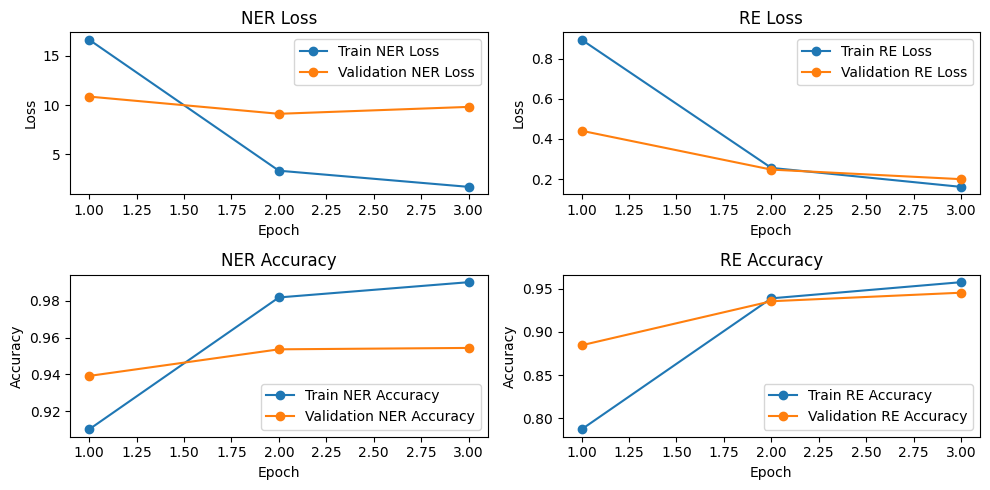

In [ ]:
import matplotlib.pyplot as plt

# Data from the training and validation process
epochs = [1, 2, 3]


# Plotting the loss curves
plt.figure(figsize=(10, 5))

# # Plot total loss
# plt.subplot(2, 2, 1)
# plt.plot(epochs, total_train_loss_list, label='Train Total Loss', marker='o')
# plt.plot(epochs, total_val_loss_list, label='Validation Total Loss', marker='o')
# plt.title('Total Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# Plot NER loss
plt.subplot(2, 2, 1)
plt.plot(epochs, ner_loss_list, label='Train NER Loss', marker='o')
plt.plot(epochs, val_ner_loss_list, label='Validation NER Loss', marker='o')
plt.title('NER Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot RE loss
plt.subplot(2, 2, 2)
plt.plot(epochs, re_loss_list, label='Train RE Loss', marker='o')
plt.plot(epochs, val_re_loss_list, label='Validation RE Loss', marker='o')
plt.title('RE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot NER accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, ner_accuracy_list, label='Train NER Accuracy', marker='o')
plt.plot(epochs, val_ner_accuracy_list, label='Validation NER Accuracy', marker='o')
plt.title('NER Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot RE accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, re_accuracy_list, label='Train RE Accuracy', marker='o')
plt.plot(epochs, val_re_accuracy_list, label='Validation RE Accuracy', marker='o')
plt.title('RE Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
# ✅ Save the whole subplot figure in high resolution (300 dpi)
plt.savefig("joint_model_accuracy.tiff", dpi=300, format='tiff')
# (Optional) Also save as PNG
plt.savefig("joint_model_accuracy.png", dpi=300)

plt.show()


In [ ]:
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report as ner_classification_report
from sklearn.metrics import classification_report as re_classification_report

import numpy as np


# def evaluate_model_on_test(model, test_dataloader):
#     model.eval()  # Set the model to evaluation mode
#     all_ner_true_labels = []
#     all_ner_predicted_labels = []
#     all_re_true_labels = []
#     all_re_predicted_labels = []

#     with torch.no_grad():
#         for batch in test_dataloader:
#             # Unpack the batch
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             entity_mask = batch['entity_mask'].to(device)
#             entity_type_ids = batch['entity_type_ids'].to(device)
#             ner_labels = batch['ner_labels'].to(device)
#             re_labels = batch['re_labels'].to(device)

#             # Forward pass
#             ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)

#             # Decode NER predictions using CRF layer
#             predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)

#             # Collect NER true labels and predictions
#             for i in range(len(predicted_ner_labels)):
#                 true_labels = ner_labels[i].cpu().numpy()
#                 pred_labels = np.array(predicted_ner_labels[i])  # Convert to NumPy array

#                 # Only consider non-padding tokens for NER accuracy
#                 valid_token_count = len(pred_labels)
#                 non_padding_indices = attention_mask[i].cpu().numpy().astype(bool)[:valid_token_count]

#                 all_ner_true_labels.append([neid2type[label] for label in true_labels[:valid_token_count] if label != 0])
#                 all_ner_predicted_labels.append([neid2type[label] for label in pred_labels if label != 0])

#             # Collect RE true labels and predictions
#             _, predicted_re_labels = torch.max(re_logits, 1)
#             all_re_true_labels.extend(re_labels.cpu().numpy())
#             all_re_predicted_labels.extend(predicted_re_labels.cpu().numpy())

#     # Generate classification reports for NER and RE
#     ner_report = ner_classification_report(all_ner_true_labels, all_ner_predicted_labels)
#     re_report = re_classification_report([reid2type[label] for label in all_re_true_labels],
#                                       [reid2type[label] for label in all_re_predicted_labels])
#     precision = precision_score(all_ner_true_labels, all_ner_predicted_labels)
#     recall = recall_score(all_ner_true_labels, all_ner_predicted_labels)
#     f1 = f1_score(all_ner_true_labels, all_ner_predicted_labels)

#     print(f"NER Precision: {precision}")
#     print(f"NER Recall: {recall}")
#     print(f"NER F1 Score: {f1}")

#     return ner_report, re_report

def evaluate_model_on_test(model, test_dataloader):
    model.eval()  # Set the model to evaluation mode
    all_ner_true_labels = []
    all_ner_predicted_labels = []
    all_re_true_labels = []
    all_re_predicted_labels = []

    with torch.no_grad():
        for batch in test_dataloader:
            # Unpack the batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Forward pass
            ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)

            # Decode NER predictions using CRF layer
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)

            # Collect NER true labels and predictions
            for i in range(len(predicted_ner_labels)):
                true_labels = ner_labels[i].cpu().numpy()
                pred_labels = np.array(predicted_ner_labels[i])  # Convert to NumPy array

                # Only consider non-padding tokens for NER accuracy
                non_padding_indices = attention_mask[i].cpu().numpy().astype(bool)

                # Ensure the number of true and predicted labels matches
                filtered_true_labels = true_labels[non_padding_indices]  # Non-padding tokens for true labels
                filtered_pred_labels = pred_labels[:len(filtered_true_labels)]  # Predicted labels with matching length

                # Add the filtered labels to the lists
                # all_ner_true_labels.append([neid2type[label] for label in filtered_true_labels if label != 0])
                # all_ner_predicted_labels.append([neid2type[label] for label in filtered_pred_labels if label != 0])

                all_ner_true_labels.append([neid2type[label] for label in filtered_true_labels])
                all_ner_predicted_labels.append([neid2type[label] for label in filtered_pred_labels])

            # Collect RE true labels and predictions
            _, predicted_re_labels = torch.max(re_logits, 1)
            all_re_true_labels.extend(re_labels.cpu().numpy())
            all_re_predicted_labels.extend(predicted_re_labels.cpu().numpy())

    # Generate classification reports for NER and RE
    ner_report = ner_classification_report(all_ner_true_labels, all_ner_predicted_labels)
    re_report = re_classification_report([reid2type[label] for label in all_re_true_labels],
                                         [reid2type[label] for label in all_re_predicted_labels])

    # Compute precision, recall, and F1 score for NER
    precision = precision_score(all_ner_true_labels, all_ner_predicted_labels)
    recall = recall_score(all_ner_true_labels, all_ner_predicted_labels)
    f1 = f1_score(all_ner_true_labels, all_ner_predicted_labels)

    print(f"NER Precision: {precision}")
    print(f"NER Recall: {recall}")
    print(f"NER F1 Score: {f1}")

    return ner_report, re_report


In [ ]:
# Evaluate the trained model on the test data
ner_report, re_report = evaluate_model_on_test(model, test_dataloader)

# Print the classification reports for NER and RE tasks
print("NER Classification Report:")
print(ner_report)
print("\nRE Classification Report:")
print(re_report)

/usr/local/lib/python3.11/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: null seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


NER Precision: 0.8971251624741953
NER Recall: 0.915642436302626
NER F1 Score: 0.9062892231641145
NER Classification Report:
              precision    recall  f1-score   support

        Area       0.90      0.93      0.91      4058
         Exp       0.95      0.94      0.95       771
    Features       0.90      0.91      0.91       423
     HackOrg       0.90      0.92      0.91      2975
      OffAct       0.85      0.93      0.89      1837
         Org       0.87      0.88      0.87      4936
        Purp       0.87      0.84      0.86       442
     SamFile       0.84      0.93      0.88       715
     SecTeam       0.91      0.93      0.92      1050
        Time       0.91      0.93      0.92      1803
        Tool       0.87      0.85      0.86      2289
         Way       0.69      0.73      0.71       610
         ull       1.00      1.00      1.00      3720

   micro avg       0.90      0.92      0.91     25629
   macro avg       0.88      0.90      0.89     25629
weighted a

In [ ]:
2 + 'p'

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [ ]:
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report as ner_classification_report
from sklearn.metrics import classification_report as re_classification_report

import numpy as np

def evaluate_model_on_test(model, test_dataloader):
    model.eval()  # Set the model to evaluation mode
    all_ner_true_labels = []
    all_ner_predicted_labels = []
    all_re_true_labels = []
    all_re_predicted_labels = []

    with torch.no_grad():
        for batch in test_dataloader:
            # Unpack the batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Forward pass
            ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)

            # Decode NER predictions using CRF layer
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)

            # Collect NER true labels and predictions
            for i in range(len(predicted_ner_labels)):
                true_labels = ner_labels[i].cpu().numpy()
                pred_labels = np.array(predicted_ner_labels[i])  # Convert to NumPy array

                # Only consider non-padding tokens for NER accuracy
                non_padding_indices = attention_mask[i].cpu().numpy().astype(bool)

                # Ensure the number of true and predicted labels matches
                filtered_true_labels = true_labels[non_padding_indices]  # Non-padding tokens for true labels
                filtered_pred_labels = pred_labels[:len(filtered_true_labels)]  # Predicted labels with matching length

                # Add the filtered labels to the lists
                # all_ner_true_labels.append([neid2type[label] for label in filtered_true_labels if label != 0])
                # all_ner_predicted_labels.append([neid2type[label] for label in filtered_pred_labels if label != 0])

                all_ner_true_labels.append([neid2type[label] for label in filtered_true_labels])
                all_ner_predicted_labels.append([neid2type[label] for label in filtered_pred_labels])

            # Collect RE true labels and predictions
            _, predicted_re_labels = torch.max(re_logits, 1)
            all_re_true_labels.extend(re_labels.cpu().numpy())
            all_re_predicted_labels.extend(predicted_re_labels.cpu().numpy())

            print("all_ner_true_labels:", all_ner_true_labels)
            print("all_ner_predicted_labels:", all_ner_predicted_labels)
            print("all_re_true_labels:", all_re_true_labels)
            print("all_re_predicted_labels:", all_re_predicted_labels)

    # Generate classification reports for NER and RE
    ner_report = ner_classification_report(all_ner_true_labels, all_ner_predicted_labels)
    re_report = re_classification_report([reid2type[label] for label in all_re_true_labels],
                                         [reid2type[label] for label in all_re_predicted_labels])

    # Compute precision, recall, and F1 score for NER
    precision = precision_score(all_ner_true_labels, all_ner_predicted_labels)
    recall = recall_score(all_ner_true_labels, all_ner_predicted_labels)
    f1 = f1_score(all_ner_true_labels, all_ner_predicted_labels)

    print(f"NER Precision: {precision}")
    print(f"NER Recall: {recall}")
    print(f"NER F1 Score: {f1}")

    return ner_report, re_report


In [ ]:
ner_report, re_port=evaluate_model_on_test(model, test_dataloader)

In [ ]:

def inference_test(model, test_dataloader, roberta_encoder):
    model.eval()  # Set the model to evaluation mode
    all_ner_true_labels = []
    all_ner_predicted_labels = []
    all_re_true_labels = []
    all_re_predicted_labels = []

    sample_triples = []  # Store sample triples for visualization

    with torch.no_grad():
        for batch in test_dataloader:
            # Unpack the batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Forward pass
            ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)

            # Decode NER predictions using CRF layer
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)

            # Decode tokens for entity extraction
            tokenizer=roberta_encoder.tokenizer
            batch_tokens = [tokenizer.convert_ids_to_tokens(ids) for ids in input_ids]

            # Collect NER true labels and predictions
            for i in range(len(predicted_ner_labels)):
                true_labels = ner_labels[i].cpu().numpy()
                pred_labels = np.array(predicted_ner_labels[i])  # Convert to NumPy array

                # Only consider non-padding tokens for NER accuracy
                non_padding_indices = attention_mask[i].cpu().numpy().astype(bool)
                filtered_true_labels = true_labels[non_padding_indices]
                filtered_pred_labels = pred_labels[:len(filtered_true_labels)]

                all_ner_true_labels.append([neid2type[label] for label in filtered_true_labels])
                all_ner_predicted_labels.append([neid2type[label] for label in filtered_pred_labels])

                # Identify entity pairs from NER predictions and generate triples for RE
                tokens = batch_tokens[i]
                entities = []  # Collect predicted entities in (text, label, index) format
                current_entity = []

                # Extract entities from predicted NER labels
                for idx, label in enumerate(filtered_pred_labels):
                    label_str = neid2type[label]  # Convert label to string
                    if label_str.startswith("B-"):
                        if current_entity:
                            entities.append(current_entity)
                        current_entity = [tokens[idx], label_str[2:], idx]
                    elif label_str.startswith("I-") and current_entity:
                        current_entity[0] += " " + tokens[idx]  # Append token to current entity text
                    elif label_str == "O" and current_entity:
                        entities.append(current_entity)
                        current_entity = []
                if current_entity:
                    entities.append(current_entity)

                # Generate triples based on entity pairs and RE predictions
                for e1, e2 in zip(entities[:-1], entities[1:]):
                    entity_pair_input = f"{e1[0]} ({e1[1]}) -> {e2[0]} ({e2[1]})"
                    predicted_relation = reid2type[torch.argmax(re_logits[i]).item()]
                    if predicted_relation != "noRelation":
                        triple = (e1[0], predicted_relation, e2[0])
                        sample_triples.append(triple)
                        print(f"Predicted Triple: {triple}")

            # Collect RE true labels and predictions
            _, predicted_re_labels = torch.max(re_logits, 1)
            all_re_true_labels.extend(re_labels.cpu().numpy())
            all_re_predicted_labels.extend(predicted_re_labels.cpu().numpy())

    # Generate classification reports for NER and RE
    ner_report = ner_classification_report(all_ner_true_labels, all_ner_predicted_labels)
    re_report = re_classification_report([reid2type[label] for label in all_re_true_labels],
                                         [reid2type[label] for label in all_re_predicted_labels])

    # Compute precision, recall, and F1 score for NER
    precision = precision_score(all_ner_true_labels, all_ner_predicted_labels)
    recall = recall_score(all_ner_true_labels, all_ner_predicted_labels)
    f1 = f1_score(all_ner_true_labels, all_ner_predicted_labels)

    print(f"NER Precision: {precision}")
    print(f"NER Recall: {recall}")
    print(f"NER F1 Score: {f1}")

    print("\nSample Entity-Relation Triples (Predictions):")
    for triple in sample_triples[:5]:  # Print a sample of 5 triples
        print(triple)

    return ner_report, re_report


In [ ]:
ner_report, re_report = inference_test(model, test_dataloader, roberta_encoder)

# **At inference, results from NER would need to be preprocessed before passing them to RE task because of the tokenization and align label function depending on the technique used in there. **

In [ ]:
# Print the classification reports for NER and RE tasks
print("NER Classification Report:")
print(ner_report)
print("\nRE Classification Report:")
print(re_report)